In [ ]:
Apex-Planet internship 
Task1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Success")

Success


In [6]:
df = pd.read_csv(r"C:\Users\vasan\apexplanet-data-analytics\data\Superstore.csv")
df.head()

,Order ID,Order Date,Customer Name,Region,Category,Sub-Category,Sales,Profit,Quantity
0,1001,05-01-2026,Alice,East,Furniture,Chairs,250.50,45.2,2
1,1002,06-01-2026,Bob,West,Technology,Phones,899.99,180.0,1
2,1003,07-01-2026,Charlie,South,Office Supplies,Binders,35.75,8.5,5
3,1004,08-01-2026,David,North,Furniture,Tables,450.00,-25.0,1
4,1005,09-01-2026,Eva,East,Technology,Laptops,1200.00,300.0,1


In [7]:
df.head()

,Order ID,Order Date,Customer Name,Region,Category,Sub-Category,Sales,Profit,Quantity
0,1001,2026-01-05,Alice,East,Furniture,Chairs,250.50,45.2,2
1,1002,2026-01-06,Bob,West,Technology,Phones,899.99,180.0,1
2,1003,2026-01-07,Charlie,South,Office Supplies,Binders,35.75,8.5,5
3,1004,2026-01-08,David,North,Furniture,Tables,450.00,-25.0,1
4,1005,2026-01-09,Eva,East,Technology,Laptops,1200.00,300.0,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       10 non-null     int64  
 1   Order Date     10 non-null     object 
 2   Customer Name  10 non-null     object 
 3   Region         10 non-null     object 
 4   Category       10 non-null     object 
 5   Sub-Category   10 non-null     object 
 6   Sales          10 non-null     float64
 7   Profit         10 non-null     float64
 8   Quantity       10 non-null     int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 852.0+ bytes


In [8]:
df.isnull().sum()

Order ID         0
Order Date       0
Customer Name    0
Region           0
Category         0
Sub-Category     0
Sales            0
Profit           0
Quantity         0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,Order ID,Sales,Profit,Quantity
count,10.00000,10.000000,10.000000,10.000000
mean,1005.50000,377.474000,66.790000,3.100000
std,3.02765,406.767249,100.096558,2.766867
min,1001.00000,18.500000,-25.000000,1.000000
25%,1003.25000,80.000000,10.125000,1.250000
50%,1005.50000,200.250000,25.000000,2.000000
75%,1007.75000,562.500000,78.800000,3.750000
max,1010.00000,1200.000000,300.000000,10.000000


In [37]:
df.tail()

,Order ID,Order Date,Customer Name,Region,Category,Sub-Category,Sales,Profit,Quantity
5,1006,2026-01-10,Frank,West,Office Supplies,Paper,18.5,4.2,10
6,1007,2026-01-11,Grace,South,Furniture,Bookcases,600.0,90.0,2
7,1008,2026-01-12,Helen,North,Technology,Accessories,75.0,20.0,3
8,1009,2026-01-13,Ian,East,Office Supplies,Storage,150.0,30.0,4
9,1010,2026-01-14,Jane,West,Furniture,Furnishings,95.0,15.0,2


In [38]:
df.shape

(10, 9)

In [39]:
df.columns

Index(['Order ID', 'Order Date', 'Customer Name', 'Region', 'Category',
       'Sub-Category', 'Sales', 'Profit', 'Quantity'],
      dtype='object')

In [43]:
import os

os.path.exists(r"C:\Users\vasan\apexplanet-data-analytics\data\Superstore.csv")

True

In [7]:
# Check missing values
print(df.isnull().sum())

# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled successfully.")

Order ID         0
Order Date       0
Customer Name    0
Region           0
Category         0
Sub-Category     0
Sales            0
Profit           0
Quantity         0
dtype: int64
Missing values handled successfully.


In [8]:
#Remove Duplicates
print("Duplicates before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [10]:
#Convert Date Columns
date_columns = ['Order Date', 'Ship Date']

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], dayfirst=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       10 non-null     int64         
 1   Order Date     10 non-null     datetime64[ns]
 2   Customer Name  10 non-null     object        
 3   Region         10 non-null     object        
 4   Category       10 non-null     object        
 5   Sub-Category   10 non-null     object        
 6   Sales          10 non-null     float64       
 7   Profit         10 non-null     float64       
 8   Quantity       10 non-null     int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 852.0+ bytes


In [11]:
#Handle Outliers (IQR Method)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Outliers removed successfully.")

Outliers removed successfully.


In [12]:
#Save Cleaned Dataset
df.to_csv("cleaned_superstore.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [13]:
#Exploratory Data Analysis (EDA)
#Dataset Summary
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, 0 to 9
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       8 non-null      int64         
 1   Order Date     8 non-null      datetime64[ns]
 2   Customer Name  8 non-null      object        
 3   Region         8 non-null      object        
 4   Category       8 non-null      object        
 5   Sub-Category   8 non-null      object        
 6   Sales          8 non-null      float64       
 7   Profit         8 non-null      float64       
 8   Quantity       8 non-null      int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 640.0+ bytes
None
          Order ID           Order Date       Sales      Profit  Quantity
count     8.000000                    8    8.000000    8.000000  8.000000
mean   1005.500000  2026-01-09 12:00:00  319.530000   45.462500  2.500000
min    1001.000000  2026-01-05 

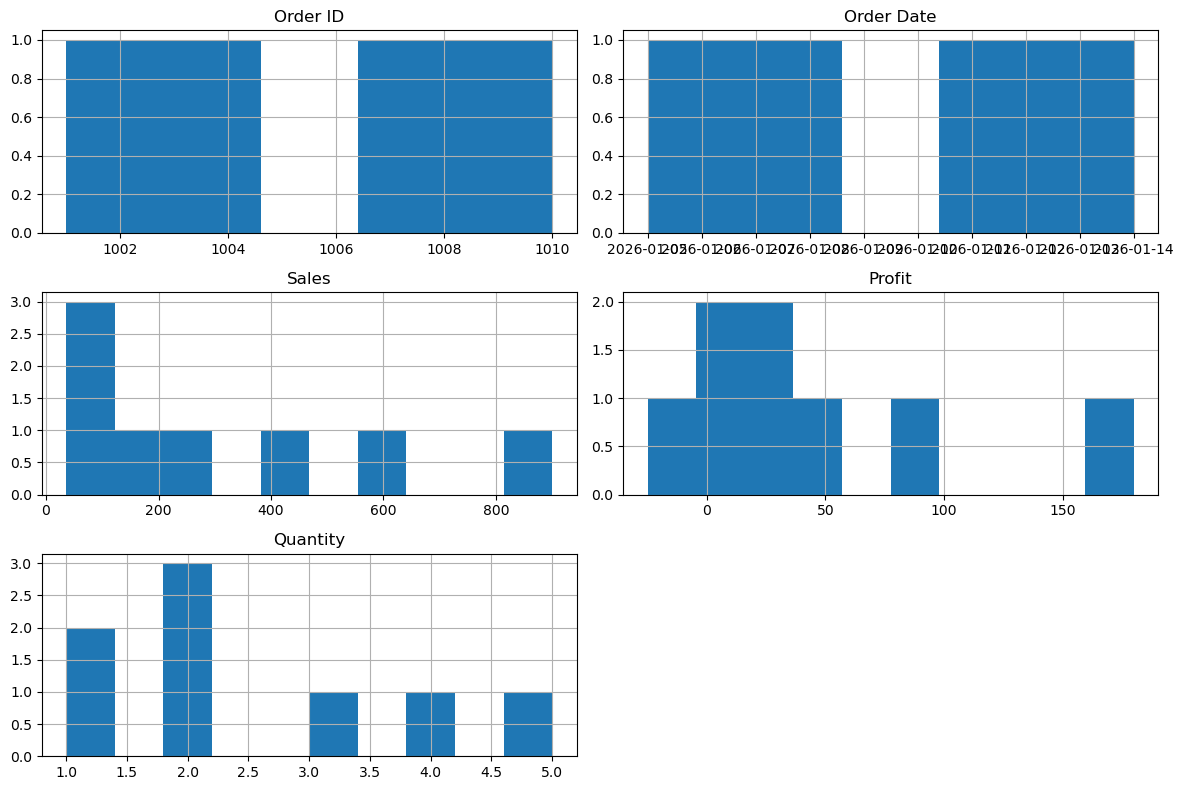

In [14]:
#Histograms
df.hist(figsize=(12,8))

plt.tight_layout()

plt.show()

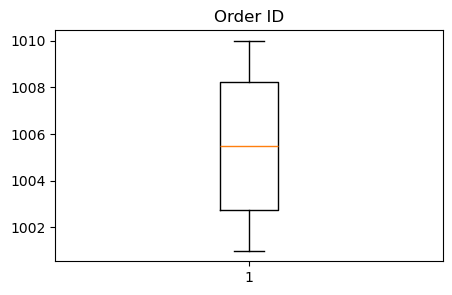

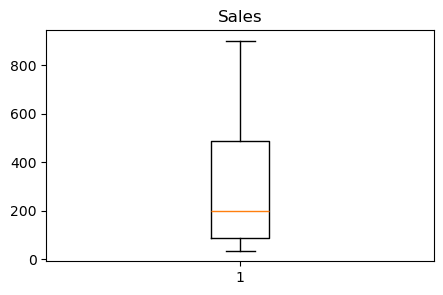

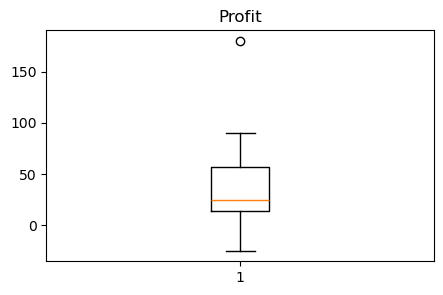

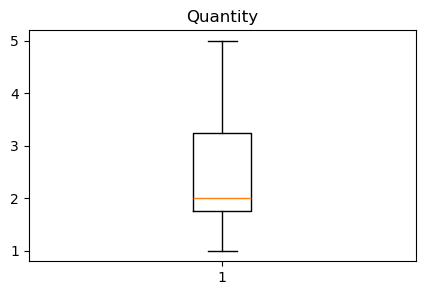

In [15]:
#Boxplots
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

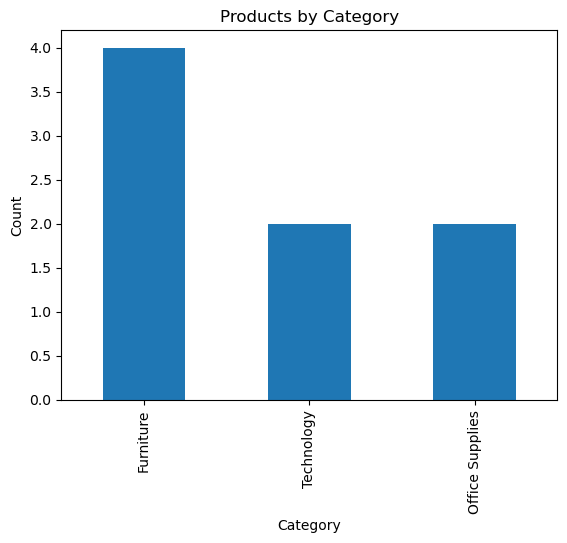

In [16]:
#Bar Chart
if 'Category' in df.columns:
    df['Category'].value_counts().plot(kind='bar')

    plt.title("Products by Category")
    plt.xlabel("Category")
    plt.ylabel("Count")

    plt.show()

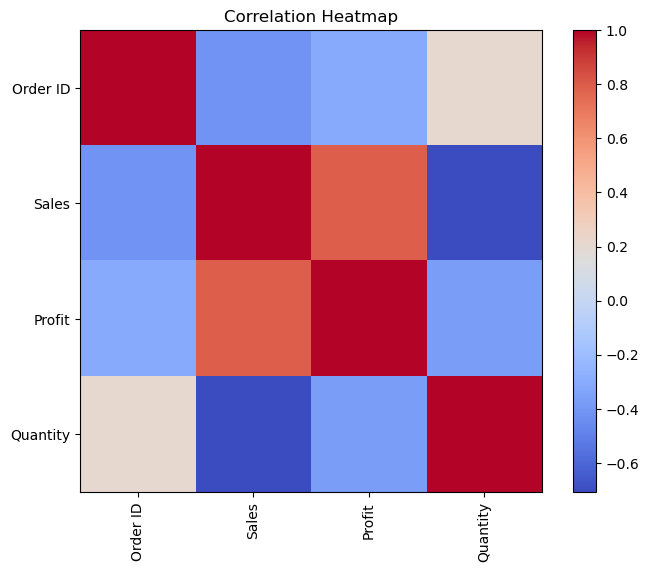

In [17]:
#Correlation Heatmap
corr = df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

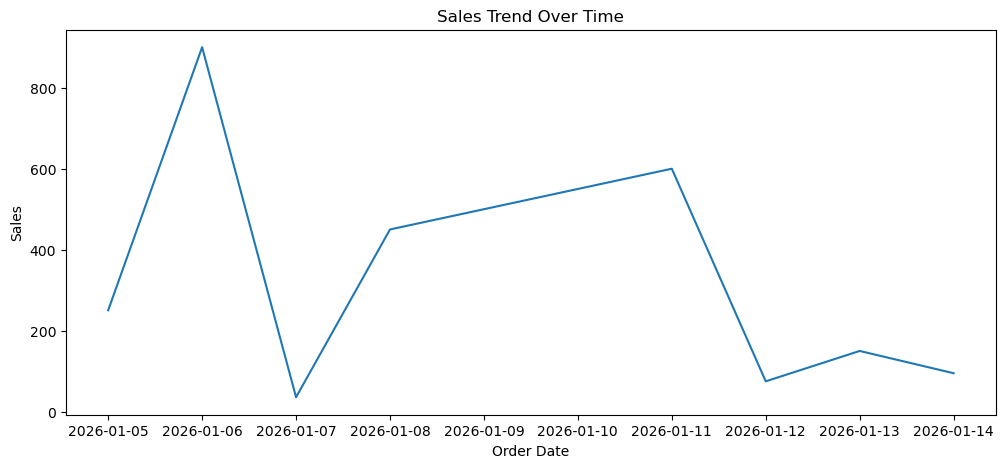

In [18]:
#Sales Trend (Line Chart)
if 'Order Date' in df.columns and 'Sales' in df.columns:

    sales = df.groupby('Order Date')['Sales'].sum()

    plt.figure(figsize=(12,5))

    plt.plot(sales.index, sales.values)

    plt.title("Sales Trend Over Time")
    plt.xlabel("Order Date")
    plt.ylabel("Sales")

    plt.show()

In [ ]:
# Key Insights

1. Missing values were handled successfully.
2. Duplicate records were removed from the dataset.
3. Outliers were detected and removed using the IQR method.
4. Sales are highest in one or more product categories, as shown in the bar chart.
5. The correlation heatmap highlights relationships between numeric variables that can support further analysis.